## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

ModuleNotFoundError: No module named 'requests'

### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

In this section, we analyze whether COGS course drop rate is associated with three course-evaluation factors from CAPE data: workload (`Study Hours per Week`), instructor rating (`Percentage Recommended Professor`), and performance (`Average Grade Received`).

To keep this section reproducible and fast to run, we directly load the processed files from `data/02-processed`:
- `capes_clean.csv` (evaluation features)
- `enroll_clean.csv` (time-series enrollment snapshots)

We first build a course-quarter drop-rate table from enrollment changes, merge it with CAPE variables, and then examine distributions and pairwise relationships using visual EDA.

#### Section 1: Build Analysis Table + Univariate Distributions

This section constructs the final EDA table at the `class x quarter` level and checks distributions/outliers for the variables used in our research question.

##### Initialization

In [14]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook', palette='deep')

# load the processed datasets
capes = pd.read_csv('data/02-processed/capes_clean.csv')
enroll = pd.read_csv('data/02-processed/enroll_clean.csv')

##### Helper functions

In [15]:
def parse_percentage(value):
    if pd.isna(value):
        return np.nan
    return float(str(value).replace('%', '').strip())

def parse_gpa(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r'\((\d+(?:\.\d+)?)\)', str(value))
    return float(match.group(1)) if match else np.nan

def extract_class_name(course_text):
    if pd.isna(course_text):
        return np.nan
    match = re.search(r'(COGS\s+\d+[A-Z]?)', str(course_text))
    return match.group(1) if match else np.nan

def compute_drop_metrics(group):
    diff = group['enrolled'].diff().fillna(0)
    total_enroll = diff[diff > 0].sum()
    total_drop = (-diff[diff < 0]).sum()
    drop_rate = (total_drop / total_enroll * 100) if total_enroll > 0 else np.nan
    return pd.Series({
        'total_enroll': total_enroll,
        'total_drop': total_drop,
        'drop_rate': drop_rate,
        'n_snapshots': len(group)
    })

##### Process data for plotting


In [21]:
enroll['time'] = pd.to_datetime(enroll['time'])
enroll = enroll.sort_values(['class', 'quarter', 'time']).copy()

drop_df = enroll.groupby(['class', 'quarter']).apply(compute_drop_metrics).reset_index()

capes = capes.copy()
capes['class'] = capes['Course'].apply(extract_class_name)
capes['quarter'] = capes['Quarter'].astype(str).str.strip().str.upper()
capes['prof_recommend_pct'] = capes['Percentage Recommended Professor'].apply(parse_percentage)
capes['grade_gpa'] = capes['Average Grade Received'].apply(parse_gpa)
capes['study_hours'] = pd.to_numeric(capes['Study Hours per Week'], errors='coerce')

eda_df = capes.merge(drop_df, on=['class', 'quarter'], how='inner')
analysis_cols = ['drop_rate', 'study_hours', 'prof_recommend_pct', 'grade_gpa']
eda_df = eda_df.dropna(subset=analysis_cols).copy()

print('Rows in final EDA table:', len(eda_df))
print('Unique course-quarter combinations:', eda_df[['class', 'quarter']].drop_duplicates().shape[0])
display(eda_df[['class', 'quarter'] + analysis_cols].head(10))
display(eda_df[analysis_cols].describe().T)

Rows in final EDA table: 81
Unique course-quarter combinations: 81


,class,quarter,drop_rate,study_hours,prof_recommend_pct,grade_gpa
0,COGS 1,SP23,25.000000,3.37,99.4,3.53
1,COGS 100,SP23,20.289855,2.52,87.0,3.96
2,COGS 101A,SP23,62.500000,4.03,88.7,3.13
3,COGS 101B,SP23,21.951220,4.01,98.9,3.56
4,COGS 107A,SP23,23.214286,5.73,93.4,3.29
5,COGS 107C,SP23,22.857143,3.96,95.9,3.74
6,COGS 108,SP23,45.312500,5.11,96.4,3.78
7,COGS 109,SP23,102.941176,6.36,87.8,3.35
8,COGS 112,SP23,58.536585,3.05,100.0,3.81
9,COGS 118A,SP23,50.000000,7.32,73.3,3.19


,count,mean,std,min,25%,50%,75%,max
drop_rate,81.0,76.187584,43.308989,11.363636,45.3125,62.50,108.571429,187.50
study_hours,81.0,4.670123,1.464799,1.170000,3.6300,4.42,5.490000,8.79
prof_recommend_pct,81.0,89.518519,14.333650,27.400000,86.7000,95.00,98.100000,100.00
grade_gpa,81.0,3.528765,0.306020,1.980000,3.3500,3.56,3.750000,4.00


##### Univariate

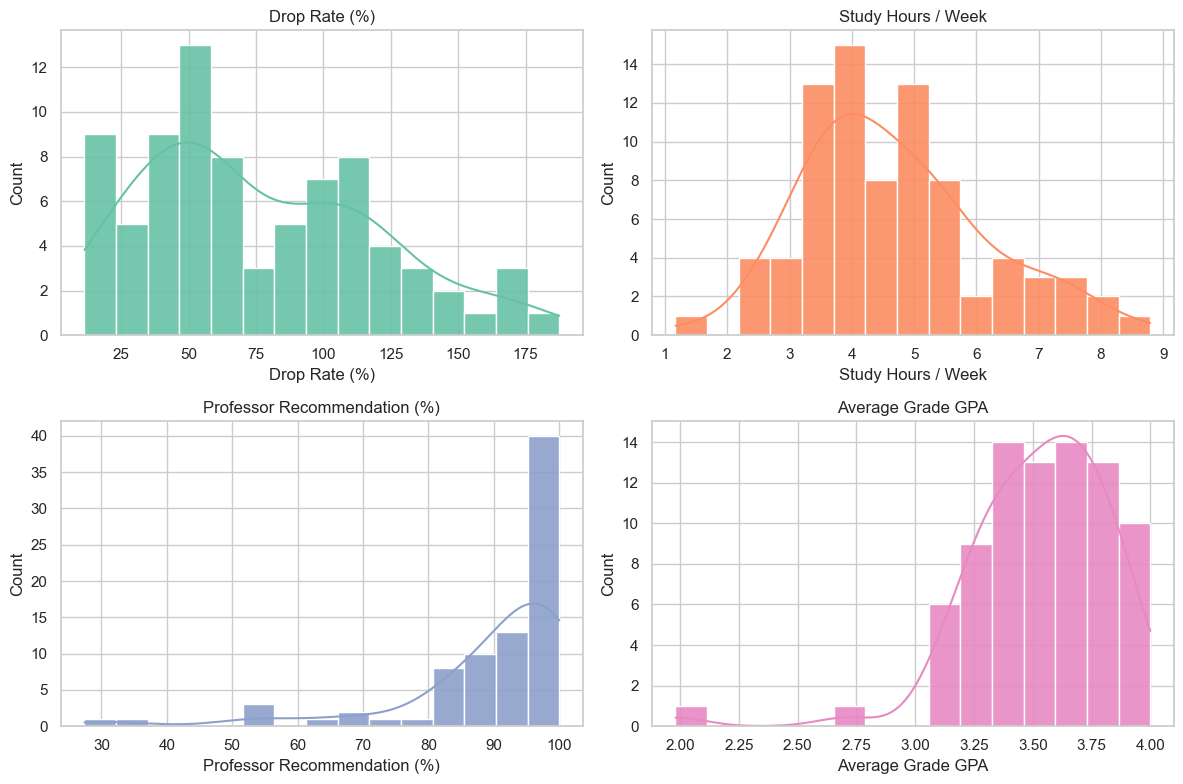

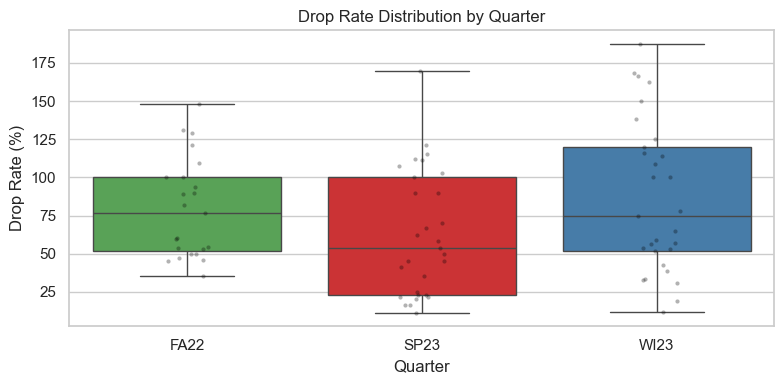

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_map = [
    ('drop_rate', 'Drop Rate (%)'),
    ('study_hours', 'Study Hours / Week'),
    ('prof_recommend_pct', 'Professor Recommendation (%)'),
    ('grade_gpa', 'Average Grade GPA')
]
hist_colors = sns.color_palette('Set2', 4)

for ax, (col, title), color in zip(axes.flatten(), plot_map, hist_colors):
    sns.histplot(data=eda_df, x=col, bins=15, kde=True, ax=ax, color=color, edgecolor='white', alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
quarter_order = sorted(eda_df['quarter'].dropna().unique())
sns.boxplot(data=eda_df, x='quarter', y='drop_rate', hue='quarter', order=quarter_order, palette='Set1', legend=False)
sns.stripplot(data=eda_df, x='quarter', y='drop_rate', order=quarter_order, color='black', alpha=0.3, size=3)
plt.title('Drop Rate Distribution by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Drop Rate (%)')
plt.tight_layout()
plt.show()

#### Section 2: Relationships Between Drop Rate and Course Factors

Here we visualize how drop rate changes with workload, recommendation rate, and average grade, then compare low-drop vs high-drop courses using quartile-based groups.

##### Bivariate Relationships

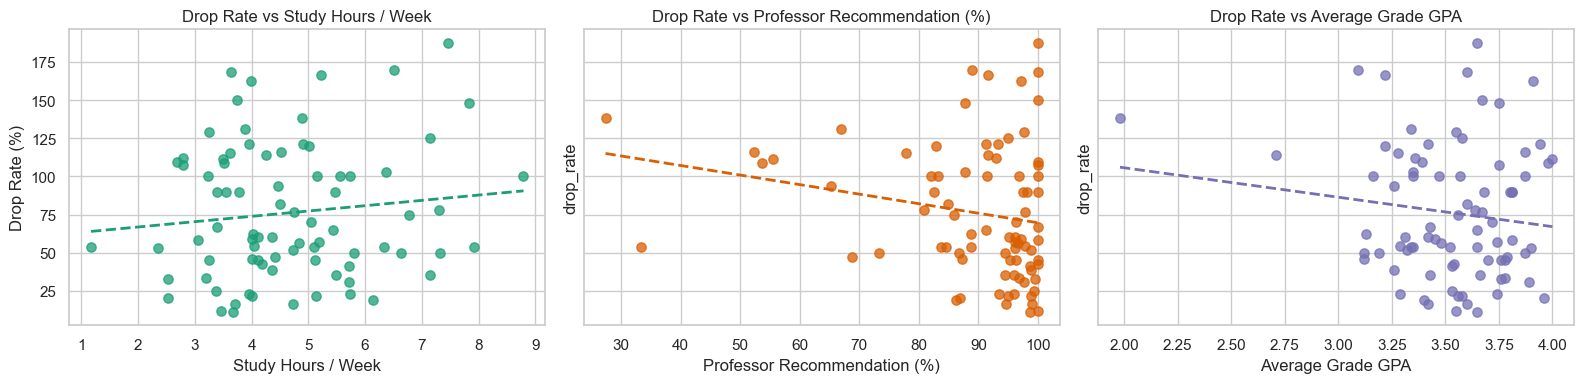

In [18]:
features = [
    ('study_hours', 'Study Hours / Week'),
    ('prof_recommend_pct', 'Professor Recommendation (%)'),
    ('grade_gpa', 'Average Grade GPA')
]
reg_colors = sns.color_palette('Dark2', 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (xcol, xlabel), color in zip(axes, features, reg_colors):
    sns.regplot(
        data=eda_df,
        x=xcol,
        y='drop_rate',
        color=color,
        scatter_kws={'alpha': 0.75, 's': 45},
        line_kws={'linestyle': '--', 'linewidth': 2},
        ci=None,
        ax=ax
    )
    ax.set_xlabel(xlabel)
    ax.set_title(f'Drop Rate vs {xlabel}')

axes[0].set_ylabel('Drop Rate (%)')
plt.tight_layout()
plt.show()

##### Quartile-based comparison

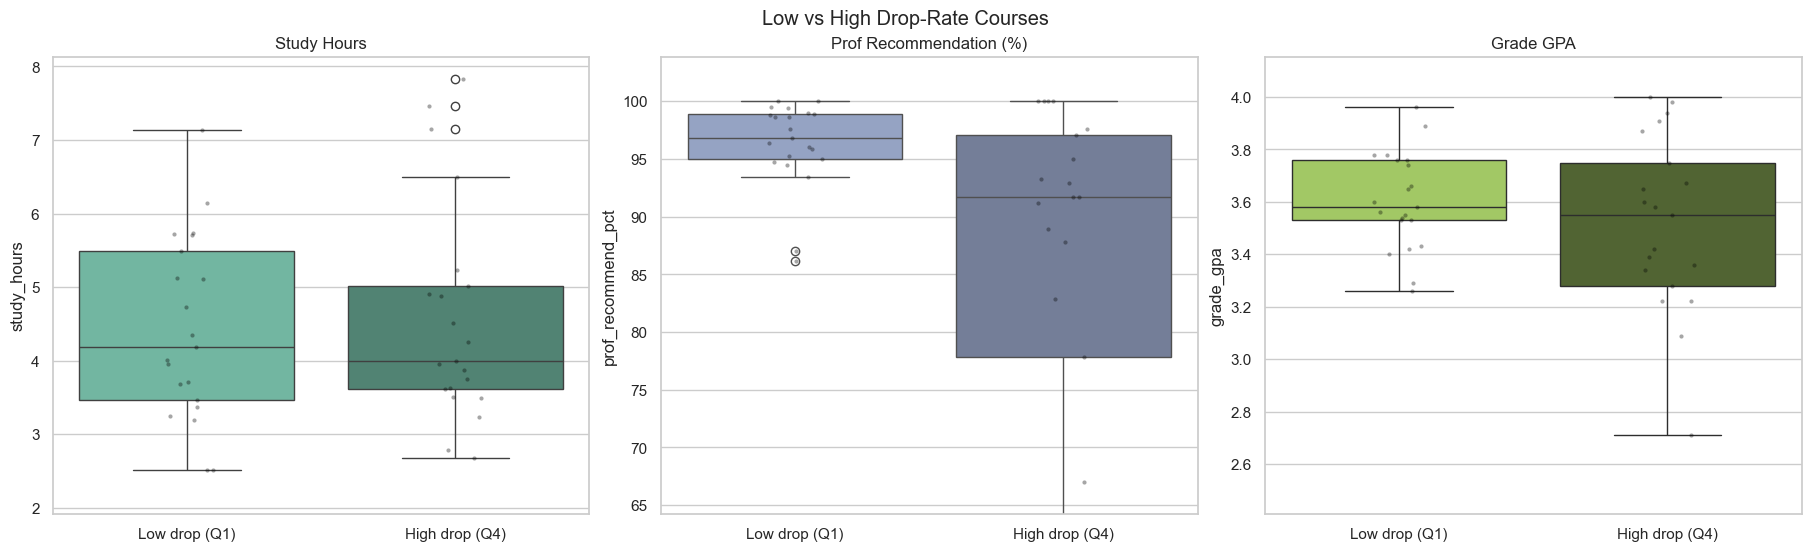

,low_drop_median,high_drop_median,difference_high_minus_low
study_hours,4.18,3.99,-0.19
prof_recommend_pct,96.80,91.70,-5.10
grade_gpa,3.58,3.55,-0.03


In [19]:
q1 = eda_df['drop_rate'].quantile(0.25)
q3 = eda_df['drop_rate'].quantile(0.75)

low_drop = eda_df[eda_df['drop_rate'] <= q1].copy()
high_drop = eda_df[eda_df['drop_rate'] >= q3].copy()
low_drop['group'] = 'Low drop (Q1)'
high_drop['group'] = 'High drop (Q4)'
compare_df = pd.concat([low_drop, high_drop], ignore_index=True)

comparison_cols = ['study_hours', 'prof_recommend_pct', 'grade_gpa']
comparison_labels = ['Study Hours', 'Prof Recommendation (%)', 'Grade GPA']
boxplot_palettes = [
    {'Low drop (Q1)': '#66c2a5', 'High drop (Q4)': '#498b76ff'},
    {'Low drop (Q1)': '#8da0cb', 'High drop (Q4)': '#6e7c9e'},
    {'Low drop (Q1)': '#a6d854', 'High drop (Q4)': '#536c2b'}
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5.4),
    constrained_layout=True
)
for ax, col, label, pal in zip(axes, comparison_cols, comparison_labels, boxplot_palettes):
    sns.boxplot(data=compare_df, x='group', y=col, hue='group', palette=pal, legend=False, ax=ax)
    sns.stripplot(data=compare_df, x='group', y=col, color='black', alpha=0.35, size=3, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('')

    vals = compare_df[col].dropna()
    if col == 'prof_recommend_pct':
        low_q, high_q = vals.quantile([0.10, 0.995])
    else:
        low_q, high_q = vals.quantile([0.02, 0.98])
    span = high_q - low_q
    pad = span * 0.12 if span > 0 else 0.1
    ax.set_ylim(low_q - pad, high_q + pad)

fig.suptitle('Low vs High Drop-Rate Courses')
plt.show()

summary = pd.DataFrame({
    'low_drop_median': low_drop[comparison_cols].median(),
    'high_drop_median': high_drop[comparison_cols].median(),
})
summary['difference_high_minus_low'] = summary['high_drop_median'] - summary['low_drop_median']
display(summary.round(3))

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them